Use this notebook to reuse one pooled fit, simulate equal numbers of pure-negative and pure-neutral lists, and generate benchmark diagnostics.


In [1]:
# import jax
# jax.config.update("jax_disable_jit", True)
# jax.config.update("jax_debug_nans", True)

import csv
import inspect
import json
import os
import warnings
from pathlib import Path
from typing import Any, Mapping, Sequence, cast, Type

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from jax import random
from matplotlib import rcParams  # type: ignore

from jaxcmr import repetition
from jaxcmr.helpers import (
    find_project_root,
    generate_trial_mask,
    import_from_string,
    load_data,
    save_dict_to_hdf5,
    save_figure,
)
from jaxcmr.simulation import simulate_h5_from_h5
from jaxcmr.summarize import summarize_parameters

warnings.filterwarnings("ignore")

Parameter Setup

In [2]:
# Run configuration
base_run_tag = "evosax_dithered_rtol1e4"
experiment_count = 10
max_subjects = 0

# Data parameters
data_tag = "HealeyKahana2014"
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
embedding_path = ""
emotion_feature_path = ""
feature_column = 6
concat_features = False
trial_query = "data['listtype'] == -1"
target_directory = "results/"
fit_dir = ""  # optional project-relative override
simulation_dir = ""  # optional project-relative override
output_stem = ""  # optional shared basename for fit and simulation files

# algorithm selection
model_name = "WeirdCMRNoStop"
make_factory_path = "jaxcmr.models.cmr.make_factory"
component_paths = {
    "mfc_create_fn": "jaxcmr.components.linear_memory.init_mfc",
    "mcf_create_fn": "jaxcmr.components.linear_memory.init_mcf",
    "context_create_fn": "jaxcmr.components.context.init",
    "termination_policy_create_fn": "jaxcmr.components.termination.NoStopTermination",
}

sim_alg_path = "jaxcmr.simulation.simulate_study_free_recall_and_forced_stop"
loss_fn_path = "jaxcmr.loss.transform_sequence_likelihood.ExcludeTerminationLikelihoodLoss"
fit_alg_path = "jaxcmr.fitting.EvosaxDE"
parameters = {
    "fixed": {
        "allow_repeated_recalls": False,
        "learn_after_context_update": False,
    },
    "free": {
        "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "shared_support": [2.220446049250313e-16, 99.9999999999999998],
        "item_support": [2.220446049250313e-16, 99.9999999999999998],
        "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
        "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
        "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
        "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998]
    },
}

# Fitting mode
subject_indices = []  # empty = all subjects (local), non-empty = specific subjects (cluster)
pooled = False  # True = single parameter set across all data

# Flow toggles
filter_repeated_recalls = True
redo_fits = False
redo_sims = False
redo_figures = True

# hyperparameters
seed = 0
relative_tolerance = 0.0001
absolute_tolerance = 0.0
popsize = 15
num_steps = 1000
cross_rate = 0.9
diff_w = (0.5, 1.0)
init = "latinhypercube"
best_of = 1
display_iterations = False

# analysis configuration
comparison_analysis_configs = [
    {
        "target": "jaxcmr.analyses.nth_item_recall.plot_conditional_nth_item_recall_curve",
        "kwargs": {"query_study_position": 1},
    },
    {
        "target": "jaxcmr.analyses.nth_item_recall.plot_conditional_nth_item_recall_curve"
    },
    {"target": "jaxcmr.analyses.nth_item_recall.plot_simple_nth_item_recall_curve"},
    {"target": "jaxcmr.analyses.spc.plot_spc"},
    {"target": "jaxcmr.analyses.crp.plot_crp"},
    {"target": "jaxcmr.analyses.pnr.plot_pnr"},
    {"target": "jaxcmr.analyses.termination_probability.plot_termination_probability"},
]

single_analysis_configs = []


In [3]:
# Parameters
base_run_tag = "pooled_evosax_set_likelihood"
experiment_count = 200
max_subjects = 0
data_tag = "TalmiEEG"
data_path = "data/TalmiEEG.h5"
figure_dir = "work/lpp_pure_list_simulations"
figure_str = "EEM_eCMR_LPP_General"
embedding_path = ""
emotion_feature_path = ""
concat_features = False
trial_query = "data['subject'] > -1"
target_directory = "work/lpp_pure_list_simulations"
fit_dir = "work/lpp_pure_list_simulations"
simulation_dir = "work/lpp_pure_list_simulations"
output_stem = "EEM_eCMR_LPP_General_best_of_3"
model_name = "EEM_eCMR_LPP_General"
make_factory_path = "lpp_ecmr.models.full_eeg_ecmr.make_factory"
component_paths = {"mfc_create_fn": "jaxcmr.components.linear_memory.init_mfc", "mcf_create_fn": "jaxcmr.components.linear_memory.init_mcf", "context_create_fn": "jaxcmr.components.context.init", "termination_policy_create_fn": "jaxcmr.components.termination.NoStopTermination"}
sim_alg_path = "jaxcmr.simulation.simulate_study_free_recall_and_forced_stop"
loss_fn_path = "jaxcmr.loss.set_permutation_likelihood.ExcludeTerminationLikelihoodLoss"
fit_alg_path = "jaxcmr.fitting.EvosaxDE"
parameters = {"fixed": {"allow_repeated_recalls": False, "learn_after_context_update": True, "lpp_inter_scale": 0.0, "source_recall_drift_rate": 1.0, "phi_emot_modulates_temporal": False}, "free": {"encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998], "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998], "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998], "shared_support": [2.220446049250313e-16, 100.0], "item_support": [2.220446049250313e-16, 100.0], "learning_rate": [2.220446049250313e-16, 0.9999999999999998], "primacy_scale": [2.220446049250313e-16, 100.0], "primacy_decay": [2.220446049250313e-16, 100.0], "choice_sensitivity": [2.220446049250313e-16, 100.0], "emotion_scale": [2.220446049250313e-16, 10.0], "lpp_main_scale": [0.0, 0.21454430108484696], "source_encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998], "source_learning_rate": [2.220446049250313e-16, 10.0]}}
subject_indices = []
pooled = True
filter_repeated_recalls = True
redo_fits = False
redo_sims = True
redo_figures = True
seed = 0
relative_tolerance = 0.0001
absolute_tolerance = 0.0
popsize = 15
num_steps = 1000
cross_rate = 0.9
diff_w = [0.5, 1.0]
init = "latinhypercube"
best_of = 3
display_iterations = True
comparison_analysis_configs = [{"target": "jaxcmr.analyses.cat_spc.plot_cat_spc", "figure_suffix": "category_recall", "kwargs": {"category_field": "condition", "category_values": [1, 2], "labels": ["Pure negative", "Pure neutral"]}, "ylim": [0.2, 0.8], "color_cycle": ["#C44E52", "#4C72B0"]}, {"target": "jaxcmr.analyses.cat_lpp_by_recall.plot_cat_lpp_by_recall", "figure_suffix": "lpp_by_recall", "kwargs": {"category_field": "condition", "labels": ["Recalled negative", "Unrecalled negative", "Recalled neutral", "Unrecalled neutral"], "category_value": [2, 1, 4, 3], "contrast_name": "Condition x Recall", "lpp_field": "EarlyLPP", "exclude_ci": True}, "ylim": [-0.6, 2.2]}]
single_analysis_configs = []


In [4]:
# derive run tag
from jaxcmr.typing import FittingAlgorithm, LossFn, TrialSimulator


run_tag = f"{base_run_tag}_best_of_{best_of}"
if max_subjects:
    run_tag += f"_nsubs_{max_subjects}"

# set up rng
rng = random.PRNGKey(seed)

# resolve paths against project root
project_root = Path(find_project_root())
target_directory = os.path.join(project_root, target_directory)
figure_dir = os.path.join(project_root, figure_dir)

# resolve and create product directories
product_dirs = {
    "fits": os.path.join(project_root, fit_dir) if fit_dir else os.path.join(target_directory, "fits"),
    "figures": figure_dir,
    "simulations": os.path.join(project_root, simulation_dir) if simulation_dir else os.path.join(target_directory, "simulations"),
}
for product_dir in product_dirs.values():
    Path(product_dir).mkdir(parents=True, exist_ok=True)

# load data
data = load_data(os.path.join(project_root, data_path), max_subjects)
trial_mask = generate_trial_mask(data, trial_query)


# Construct the shared pure-list simulation inputs while retaining the original
# mixed-list dataset for loading the pooled fit and drawing empirical curves.
pure_list_design_path = project_root / "work/lpp_pure_list_simulations/pure_list_design.csv"
with pure_list_design_path.open(newline="") as handle:
    pure_list_design = list(csv.DictReader(handle))

trial_count = np.asarray(data["subject"]).shape[0]
design_trial_indices = np.array(
    [int(row["trial_index"]) for row in pure_list_design], dtype=np.int32
)
design_subjects = np.array(
    [int(row["subject"]) for row in pure_list_design], dtype=np.int32
)
design_lists = np.array(
    [int(row["list"]) for row in pure_list_design], dtype=np.int32
)
pure_conditions = np.array(
    [int(row["condition"]) for row in pure_list_design], dtype=np.int32
)

if not np.array_equal(design_trial_indices, np.arange(trial_count)):
    raise ValueError("pure_list_design.csv does not match the data trial order.")
if not np.array_equal(design_subjects, np.asarray(data["subject"]).reshape(-1)):
    raise ValueError("pure_list_design.csv does not match the data subjects.")
if not np.array_equal(design_lists, np.asarray(data["list"]).reshape(-1)):
    raise ValueError("pure_list_design.csv does not match the data list identifiers.")

simulation_fields = (
    "EarlyLPP",
    "list",
    "listLength",
    "pres_itemids",
    "pres_itemnos",
    "recalls",
    "subject",
)
simulation_data = {
    key: np.array(data[key], copy=True) for key in simulation_fields
}
simulation_data["condition"] = np.repeat(
    pure_conditions[:, np.newaxis],
    np.asarray(data["condition"]).shape[1],
    axis=1,
).astype(np.int32)
simulation_data["list_type"] = pure_conditions[:, np.newaxis]

if np.count_nonzero(pure_conditions == 1) != trial_count // 2:
    raise AssertionError("Expected exactly half pure-negative trials.")
if np.count_nonzero(pure_conditions == 2) != trial_count // 2:
    raise AssertionError("Expected exactly half pure-neutral trials.")
if not np.all(simulation_data["condition"][pure_conditions == 1] == 1):
    raise AssertionError("A pure-negative trial contains a neutral item.")
if not np.all(simulation_data["condition"][pure_conditions == 2] == 2):
    raise AssertionError("A pure-neutral trial contains a negative item.")

print(
    f"Pure-list simulation design: {np.count_nonzero(pure_conditions == 1)} "
    f"negative and {np.count_nonzero(pure_conditions == 2)} neutral lists"
)

# load feature blocks
semantic_features = None
if embedding_path:
    semantic_features = np.load(project_root / embedding_path).astype(np.float32)

categorical_column = None
if emotion_feature_path:
    emotion_features = np.load(project_root / emotion_feature_path).astype(np.float32)
    categorical_column = emotion_features[:, feature_column : feature_column + 1]

modeling_features = semantic_features
if concat_features:
    modeling_features = np.concatenate([categorical_column, semantic_features], axis=1)  # type: ignore

# import analyses
comparison_analyses = []
for config in comparison_analysis_configs:
    analysis_fn = import_from_string(config["target"])
    figure_suffix = config.get("figure_suffix")
    if figure_suffix is None:
        name = getattr(analysis_fn, "__name__", "analysis")
        figure_suffix = name[5:] if name.startswith("plot_") else name
    labels = tuple(cast(Sequence[str], config.get("labels", ("Model", "Data"))))
    contrast_name = config.get("contrast_name", "Source")
    extra_kwargs = dict(cast(Mapping[str, Any], config.get("kwargs", {})))

    analysis_name = analysis_fn.__name__
    if "dist_" in analysis_name and semantic_features is not None:
        extra_kwargs.setdefault("features", semantic_features)
    elif "cat_" in analysis_name and categorical_column is not None:
        extra_kwargs.setdefault("features", categorical_column)

    comparison_analyses.append(
        {
            'target': analysis_fn,
            'figure_suffix': str(figure_suffix),
            'labels': labels,
            'contrast_name': str(contrast_name),
            'kwargs': extra_kwargs,
            'ylim': config.get('ylim', None),
            'color_cycle': config.get('color_cycle', None)
        }
    )


single_analyses = []
for config in single_analysis_configs:
    analysis_fn = import_from_string(config["target"])
    figure_suffix = config.get("figure_suffix")
    if figure_suffix is None:
        name = getattr(analysis_fn, "__name__", "analysis")
        figure_suffix = name[5:] if name.startswith("plot_") else name
    labels = tuple(cast(Sequence[str], config.get("labels", ("Model",))))
    contrast_name = config.get("contrast_name", "Source")
    extra_kwargs = dict(cast(Mapping[str, Any], config.get("kwargs", {})))

    analysis_name = analysis_fn.__name__
    if "dist_" in analysis_name and semantic_features is not None:
        extra_kwargs.setdefault("features", semantic_features)
    elif "cat_" in analysis_name and categorical_column is not None:
        extra_kwargs.setdefault("features", categorical_column)

    single_analyses.append(
        {
            'target': analysis_fn,
            'figure_suffix': str(figure_suffix),
            'labels': labels,
            'contrast_name': str(contrast_name),
            'kwargs': extra_kwargs,
            'ylim': config.get('ylim', None),
            'color_cycle': config.get('color_cycle', None)
        }
    )

# configure model factory
make_factory = import_from_string(make_factory_path)
model_factory_cls = make_factory(
    **{key: import_from_string(path) for key, path in component_paths.items()}
)

# import fitting and simulation functions
fitting_algorithm_cls: Type[FittingAlgorithm] = import_from_string(fit_alg_path)
loss_fn_cls: Type[LossFn] = import_from_string(loss_fn_path)
simulate_trial_fn: TrialSimulator = import_from_string(sim_alg_path)

# derive list of query parameters from keys of `parameters`
query_parameters = list(parameters["free"].keys())

# make sure repeatedrecalls is in either both data_tag or data_path, or is in neither
if "repeatedrecalls" in data_tag.lower() or "repeatedrecalls" in data_path.lower():
    if (
        "repeatedrecalls" not in data_tag.lower()
        and "repeatedrecalls" not in data_path.lower()
    ):
        raise ValueError(
            "If 'repeatedrecalls' is in data_tag or data_path, it must be in both."
        )

Pure-list simulation design: 171 negative and 171 neutral lists


Fit model.

In [5]:
from jaxcmr.helpers import make_subject_trial_masks

fit_stem = output_stem or f"{data_tag}_{model_name}_{run_tag}"
fit_path = Path(product_dirs["fits"]) / f"{fit_stem}.json"
metadata = {
    "run_tag": run_tag,
    "data_tag": data_tag,
    "trial_query": trial_query,
    "model": model_name,
    "name": fit_stem,
    "components": component_paths,
    "fit_algorithm": fit_alg_path,
    "loss_function": loss_fn_path,
    "model_factory": make_factory_path,
    "embedding_path": embedding_path,
    "emotion_feature_path": emotion_feature_path,
    "feature_column": str(feature_column),
    "concat_features": str(concat_features),
}

# Determine output path: per-subject partial or full
if subject_indices:
    sub_label = "_".join(str(i) for i in subject_indices)
    fit_path = Path(product_dirs["fits"]) / f"{fit_stem}_sub{sub_label}.json"

if fit_path.exists() and not redo_fits:
    with fit_path.open() as handle:
        results = json.load(handle)
    if "subject" not in results["fits"]:
        results["fits"]["subject"] = results.get("subject", [])
    results |= metadata

else:
    fitter = fitting_algorithm_cls(
        data,
        modeling_features,
        parameters["fixed"],
        model_factory_cls,
        loss_fn_cls,
        hyperparams={
            "num_steps": num_steps,
            "pop_size": popsize,
            "relative_tolerance": relative_tolerance,
            "absolute_tolerance": absolute_tolerance,
            "cross_over_rate": cross_rate,
            "diff_w": diff_w,
            "init": init,
            "progress_bar": True,
            "display_iterations": display_iterations,
            "best_of": best_of,
            "seed": seed,
            "bounds": parameters["free"],
        },
    )

    if pooled:
        results = fitter.fit(trial_mask)
    elif subject_indices:
        subject_masks, unique_subjects = make_subject_trial_masks(
            trial_mask, data["subject"].flatten()
        )
        combined_mask = jnp.zeros_like(trial_mask, dtype=bool)
        for idx in subject_indices:
            combined_mask = combined_mask | subject_masks[idx]
        if len(subject_indices) == 1:
            results = fitter.fit(combined_mask, subject_id=int(unique_subjects[subject_indices[0]]))
        else:
            results = fitter.fit_subjects(combined_mask)
    else:
        results = fitter.fit_subjects(trial_mask)

    results |= metadata
    with fit_path.open("w") as handle:
        json.dump(results, handle, indent=4)

print(
    summarize_parameters(
        [results],
        query_parameters,
        include_std=not pooled and not subject_indices,
        include_ci=not pooled and not subject_indices,
    )
)

| Parameter | Statistic | EEM eCMR LPP General best of 3 |
|---|---|---|
| fitness | mean | 8251.12 |
|  | min | 8251.12 |
|  | max | 8251.12 |
| encoding drift rate | mean | 0.00 |
|  | min | 0.00 |
|  | max | 0.00 |
| start drift rate | mean | 0.03 |
|  | min | 0.03 |
|  | max | 0.03 |
| recall drift rate | mean | 0.05 |
|  | min | 0.05 |
|  | max | 0.05 |
| shared support | mean | 74.64 |
|  | min | 74.64 |
|  | max | 74.64 |
| item support | mean | 48.98 |
|  | min | 48.98 |
|  | max | 48.98 |
| learning rate | mean | 0.28 |
|  | min | 0.28 |
|  | max | 0.28 |
| primacy scale | mean | 2.36 |
|  | min | 2.36 |
|  | max | 2.36 |
| primacy decay | mean | 2.12 |
|  | min | 2.12 |
|  | max | 2.12 |
| choice sensitivity | mean | 1.19 |
|  | min | 1.19 |
|  | max | 1.19 |
| emotion scale | mean | 7.52 |
|  | min | 7.52 |
|  | max | 7.52 |
| lpp main scale | mean | 0.21 |
|  | min | 0.21 |
|  | max | 0.21 |
| source encoding drift rate | mean | 0.73 |
|  | min | 0.73 |
|  | max | 0.73 |
| 

Simulate from fitted parameters.

In [6]:
#| code-summary: either load or perform model simulations

sim_path = os.path.join(
    product_dirs["simulations"], f"{fit_stem}.h5"
)
if subject_indices:
    sub_label = "_".join(str(i) for i in subject_indices)
    sim_path = os.path.join(
        product_dirs["simulations"], f"{fit_stem}_sub{sub_label}.h5"
    )
print(sim_path)

if redo_sims or redo_figures:
    rng, rng_iter = random.split(rng)
    params = {key: jnp.array(val) for key, val in results["fits"].items()}  # type: ignore

    if pooled:
        unique_subjects = jnp.unique(jnp.array(simulation_data["subject"]))
        n_subjects = unique_subjects.shape[0]
        params = {
            key: jnp.repeat(val, n_subjects) if key != "subject" else unique_subjects
            for key, val in params.items()
        }

    # Use per-subject mask for simulation when subject_indices is set
    sim_trial_mask = trial_mask
    if subject_indices:
        from jaxcmr.helpers import make_subject_trial_masks as _make_masks
        _subj_masks, _ = _make_masks(trial_mask, data["subject"].flatten())
        sim_trial_mask = jnp.zeros_like(trial_mask, dtype=bool)
        for _idx in subject_indices:
            sim_trial_mask = sim_trial_mask | _subj_masks[_idx]

    if os.path.exists(sim_path) and not redo_sims:
        sim = load_data(sim_path)
        print(f"Loaded from {sim_path}")

    else:
        sim = simulate_h5_from_h5(
            model_factory_cls,
            simulation_data,
            modeling_features,
            params,
            sim_trial_mask,
            experiment_count,
            rng_iter,
            simulate_trial_fn=simulate_trial_fn,
        )

        save_dict_to_hdf5(sim, sim_path)  # type: ignore
        print(f"Saved to {sim_path}")

    if filter_repeated_recalls:
        sim["recalls"] = repetition.filter_repeated_recalls(sim["recalls"])
else:
    print(f"Skipping simulations: {sim_path}")

/Users/jordangunn/workspace/lpp_ecmr/work/lpp_pure_list_simulations/EEM_eCMR_LPP_General_best_of_3.h5


Loaded from /Users/jordangunn/workspace/lpp_ecmr/work/lpp_pure_list_simulations/EEM_eCMR_LPP_General_best_of_3.h5


Figures summarize the pure-list simulations.


In [7]:
#|code-summary: single-dataset views

if redo_figures:
    for analysis_cfg in single_analyses:
        analysis_fn = analysis_cfg["target"]
        analysis_suffix = analysis_cfg["figure_suffix"]

        trial_mask = generate_trial_mask(data, trial_query)
        sim_trial_mask = generate_trial_mask(sim, trial_query)

        for dataset_label, (dataset, trial_mask) in zip(
            ["data", "sim"], [(data, trial_mask), (sim, sim_trial_mask)]
        ):

            if analysis_cfg.get("color_cycle") is None:
                color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]
            else:
                color_cycle = analysis_cfg["color_cycle"].copy()

            base_kwargs = {
                "datasets": dataset,
                "trial_masks": np.array(trial_mask),
                "color_cycle": color_cycle,
                "labels": list(analysis_cfg["labels"]),
                "contrast_name": analysis_cfg["contrast_name"],
                "axis": None,
            }
            base_kwargs |= analysis_cfg["kwargs"]

            signature = inspect.signature(analysis_fn)
            filtered_kwargs = {
                name: value
                for name, value in base_kwargs.items()
                if name in signature.parameters
            }

            figure_path = (
                os.path.join(
                    figure_dir, f"{figure_str}_{analysis_suffix}_{dataset_label}.png"
                )
                if figure_str
                else None
            )
            if figure_path and os.path.exists(figure_path) and not redo_figures:
                display(Image(filename=figure_path))
                continue

            axis = analysis_fn(**filtered_kwargs)

            if analysis_cfg["ylim"] is not None:
                plt.ylim(analysis_cfg["ylim"])

            # Only save sim figures - data figures are identical across models
            # and are generated separately by reference analysis notebooks.
            if dataset_label == "sim":
                if figure_path:
                    print(f"![]({figure_path})")
                save_figure(
                    figure_dir,
                    figure_str,
                    suffix=f"{analysis_suffix}_{dataset_label}",
                )

![](/Users/jordangunn/workspace/lpp_ecmr/work/lpp_pure_list_simulations/EEM_eCMR_LPP_General_category_recall.png)
plot_cat_spc


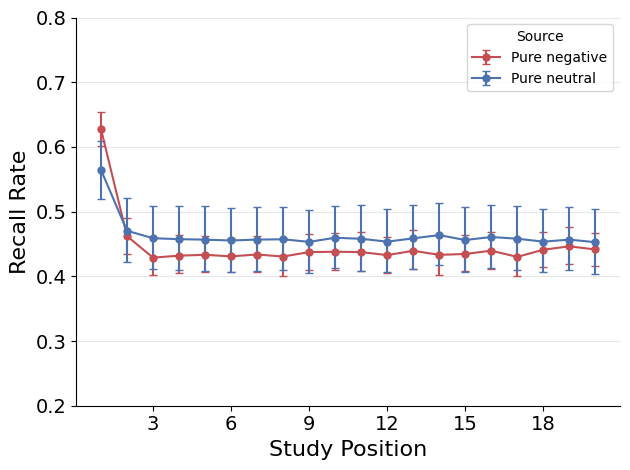

![](/Users/jordangunn/workspace/lpp_ecmr/work/lpp_pure_list_simulations/EEM_eCMR_LPP_General_lpp_by_recall.png)
plot_cat_lpp_by_recall


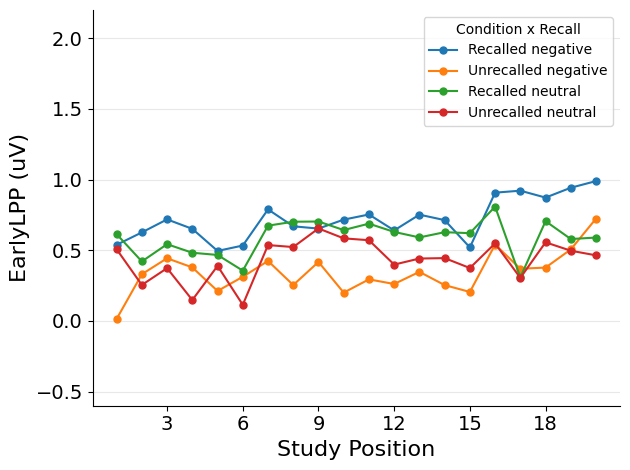

In [8]:
# code-summary: generate figures comparing model and data
if redo_figures:
    for analysis_cfg in comparison_analyses:
        analysis_fn = analysis_cfg['target']
        analysis_suffix = analysis_cfg["figure_suffix"]
        figure_path = os.path.join(figure_dir, f"{figure_str}_{analysis_suffix}.png") if figure_str else None
        if figure_path:
            print(f"![]({figure_path})")

        if figure_path and os.path.exists(figure_path) and not redo_figures:
            display(Image(filename=figure_path))
            continue

        if analysis_cfg.get('color_cycle') is None:
            color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]
        else:
            color_cycle = analysis_cfg['color_cycle'].copy()

        trial_mask = generate_trial_mask(data, trial_query)
        sim_trial_mask = generate_trial_mask(sim, trial_query)

        base_kwargs = {
            "datasets": [sim],
            "trial_masks": [np.array(sim_trial_mask)],
            "color_cycle": color_cycle,
            "labels": list(analysis_cfg['labels']),
            "contrast_name": analysis_cfg['contrast_name'],
            "axis": None,
        }
        base_kwargs |= analysis_cfg['kwargs']

        signature = inspect.signature(analysis_fn)
        print(analysis_fn.__name__)
        filtered_kwargs = {
            name: value
            for name, value in base_kwargs.items()
            if name in signature.parameters
        }

        axis = analysis_fn(**filtered_kwargs)

        if analysis_cfg.get('ylim') is not None:
            axis.set_ylim(analysis_cfg['ylim'])
        save_figure(figure_dir, figure_str, suffix=analysis_suffix)